In [1]:
import matplotlib.pyplot as plt
from src.dataset.postprocess import PostprocessingWrapper
from src.dataset.postprocess import ttest_related_ride_metrics

In [2]:
JSON_A = "/workspaces/master-diploma/scripts/resources/rt_benchmark_10_full_rides.json"
JSON_B = "/workspaces/master-diploma/scripts/resources/rt_benchmark_10_full_rides_kalman.json"

In [3]:
postproc_A = PostprocessingWrapper(JSON_A)
postproc_B = PostprocessingWrapper(JSON_B)

### Analyze rides without Kalman filter

In [4]:
postproc_A.get_ride_avg_metrics_df()

,mean,std,MSE,MAE,q95_abs,RMSE
vx,-0.183397,0.434314,0.296939,0.318444,0.891951,0.487595
vy,0.065217,0.158882,0.033649,0.125675,0.343125,0.172876
vz,0.009104,0.209828,0.051815,0.135309,0.431561,0.212434
wx,0.000083,0.017361,0.000342,0.011141,0.034810,0.017363
wy,-0.000141,0.014850,0.000241,0.009576,0.030396,0.014868
wz,0.000095,0.007266,0.000054,0.004975,0.014874,0.007271


Figure saved to ../pictures/hists/hist_full_no_kalman.png


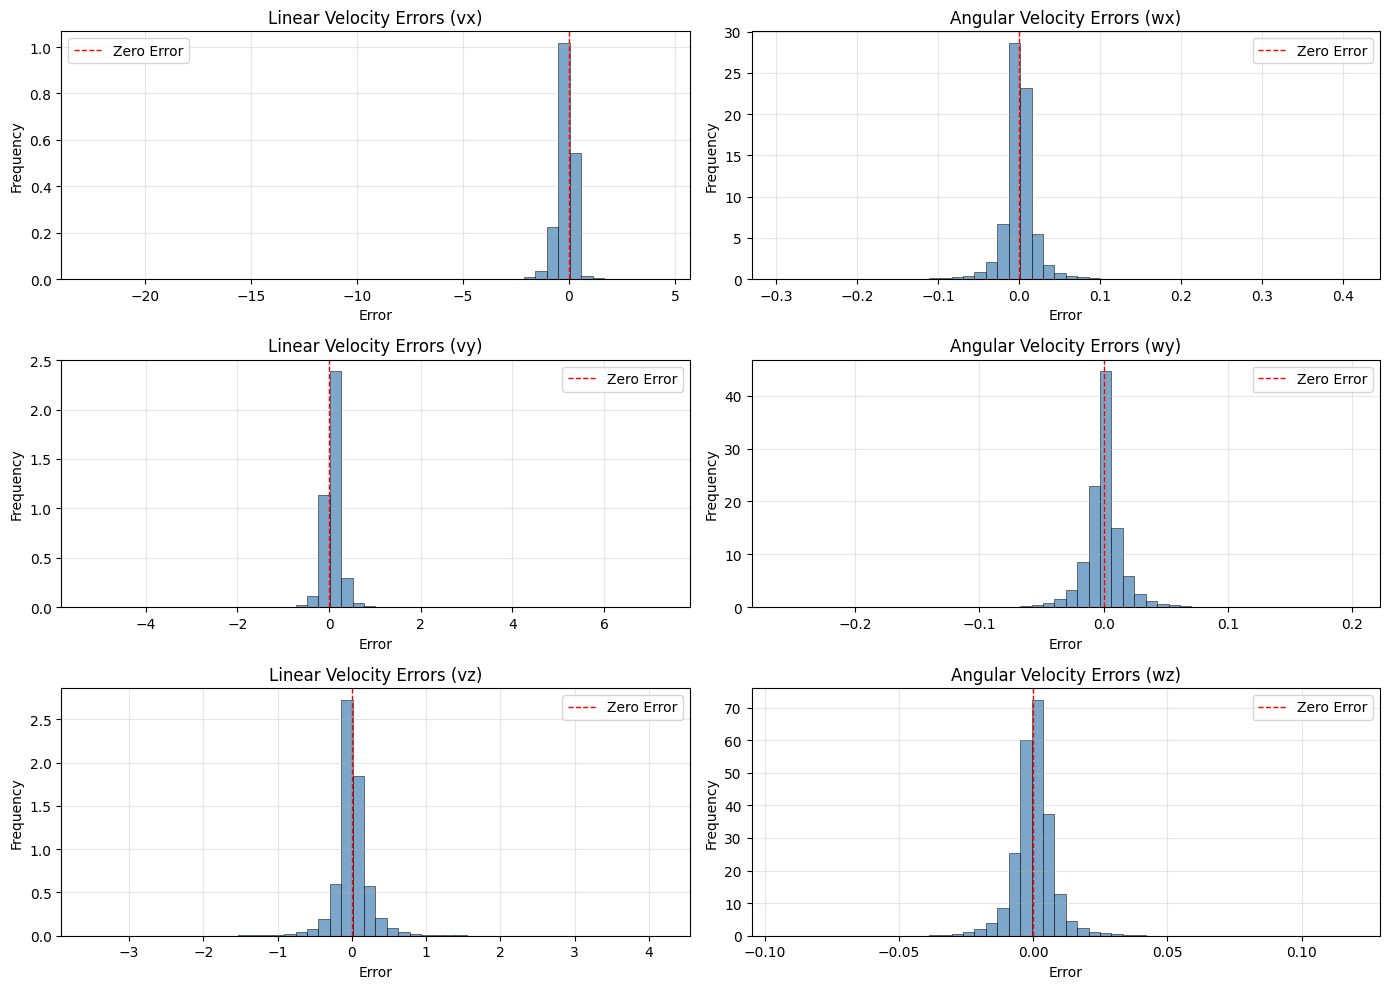

In [5]:
hist = postproc_A.plot_velocity_errors(save_path = "../pictures/hists/hist_full_no_kalman.png")
plt.show()

Figure saved to ../pictures/hists/hist_full_filtered_no_kalman.png


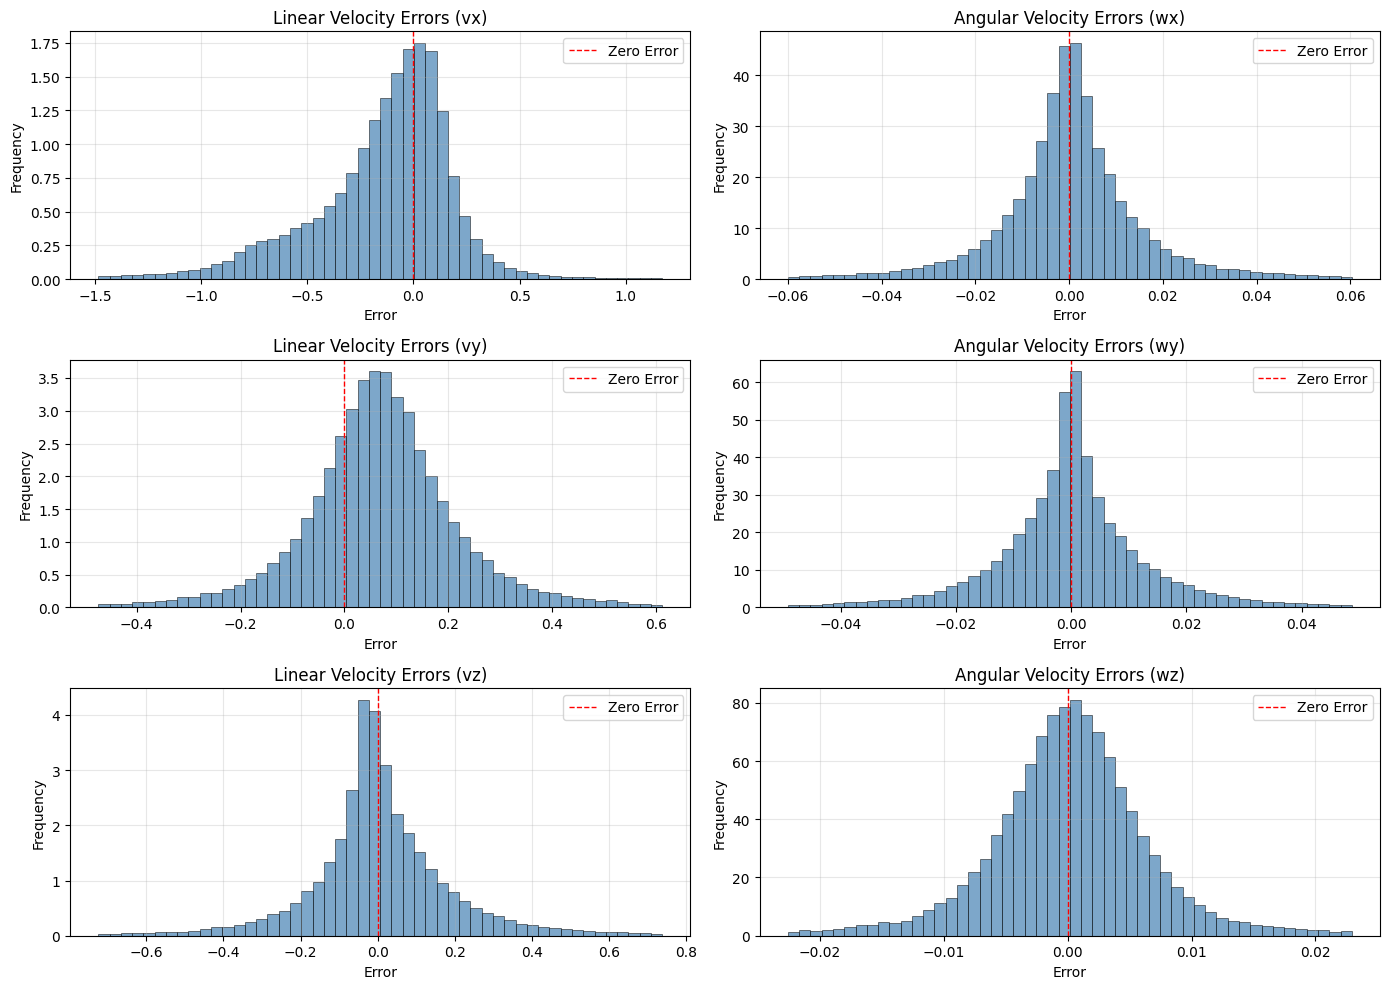

In [6]:
hist = postproc_A.plot_velocity_errors(
    outliers_threshold=3, save_path="../pictures/hists/hist_full_filtered_no_kalman.png"
)
plt.show()

In [7]:
ride_ids_to_compare = [(1, 200, 500), (3, 200, 500)]

Figure saved to ../pictures/plots/1_200_500_no_kalman.png
Figure saved to ../pictures/plots/3_200_500_no_kalman.png


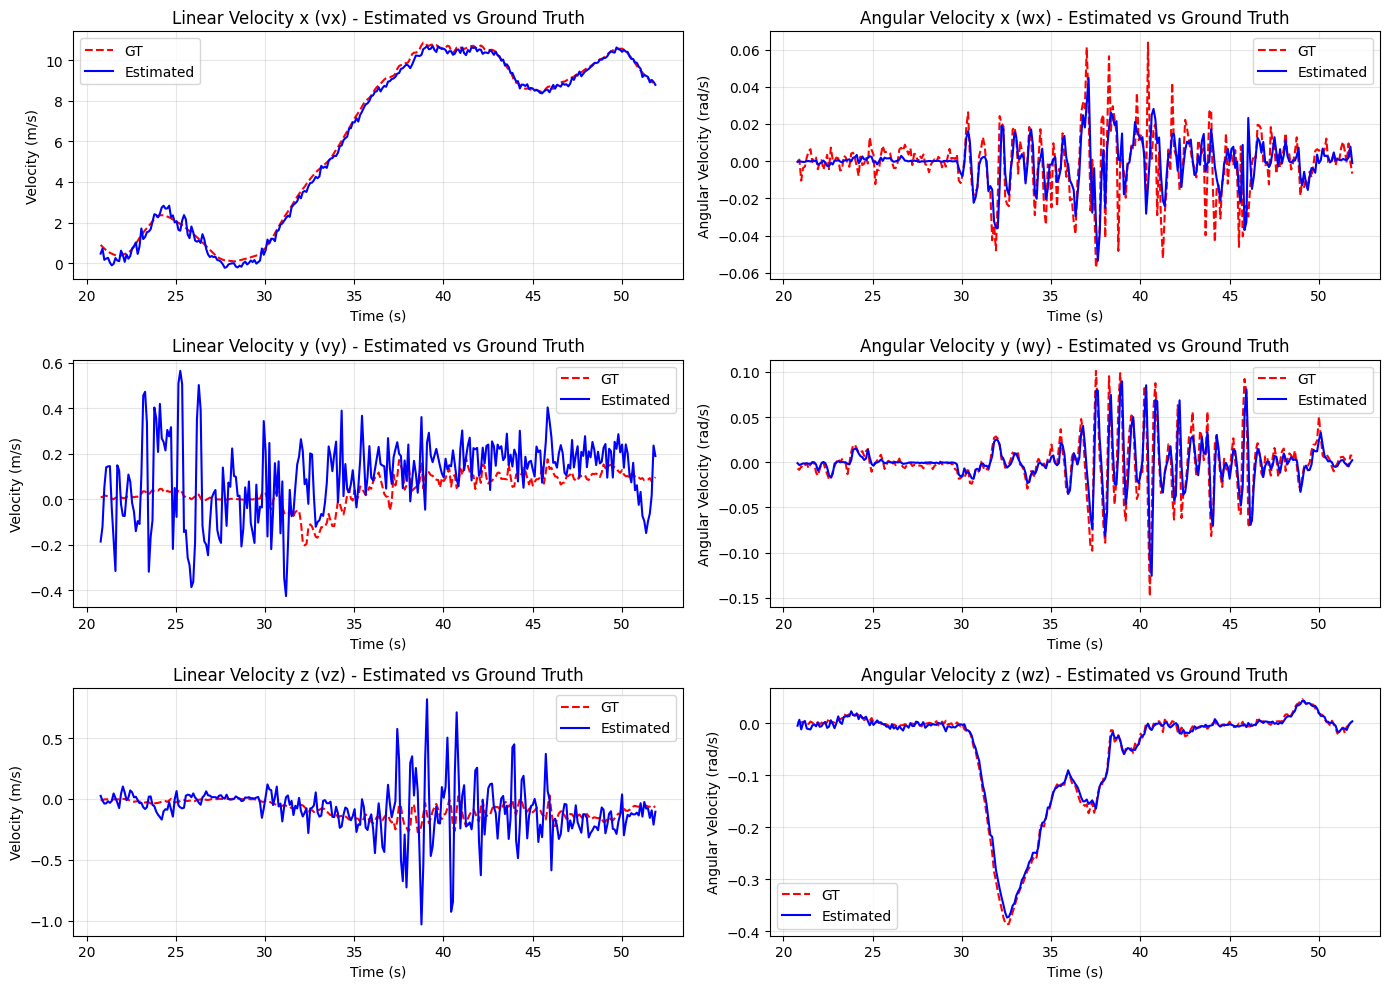

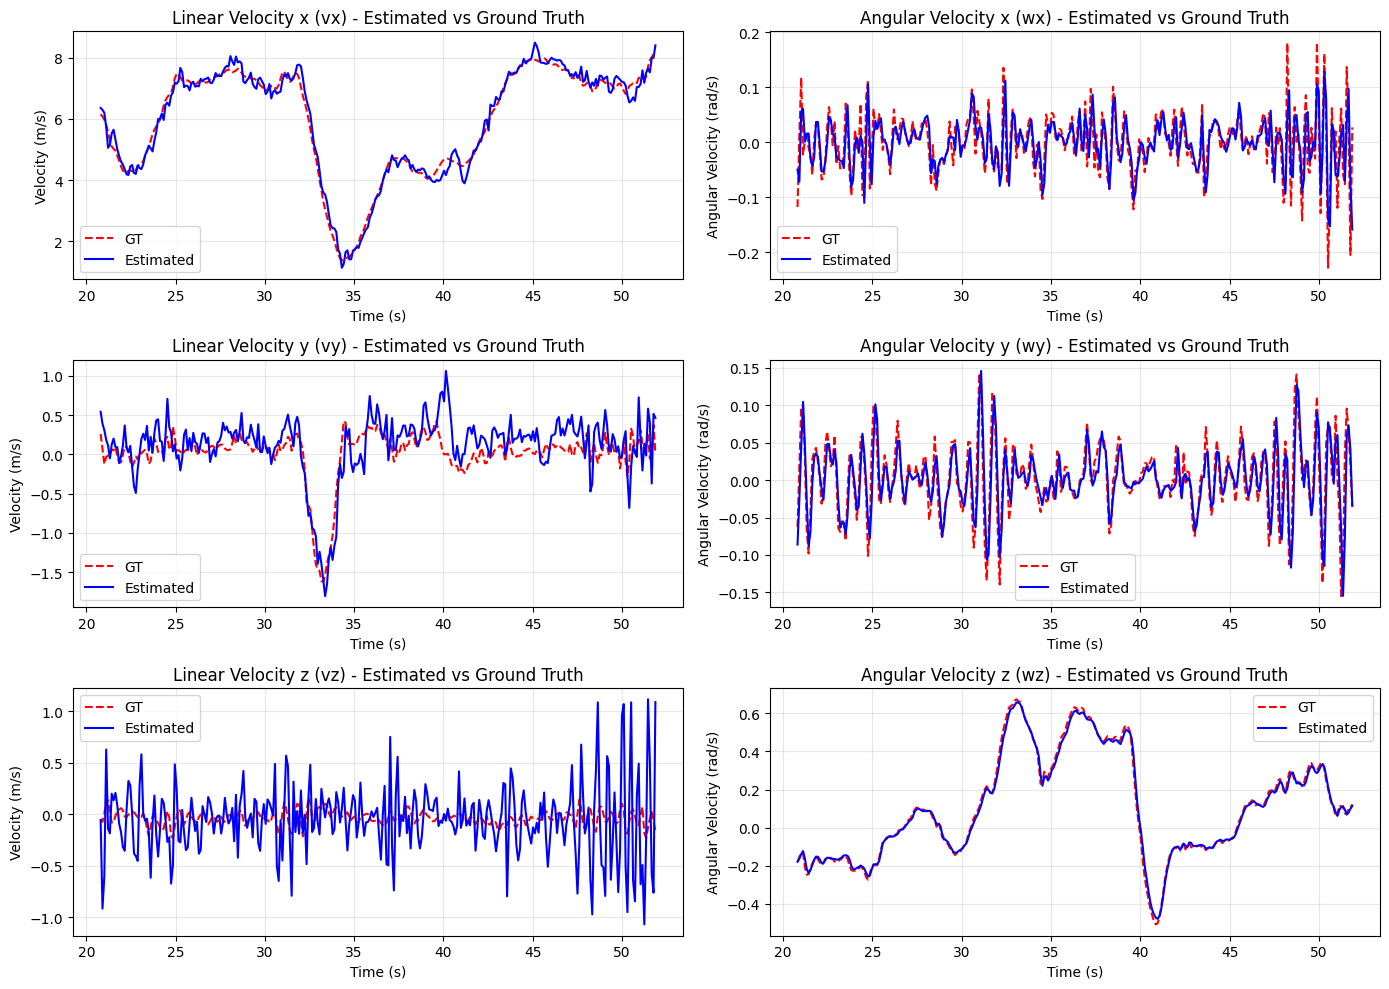

In [8]:
for ride_id, frame_st, frame_en in ride_ids_to_compare:
    fig = postproc_A.plot_velocities(
        ride_segment_id=ride_id,
        frame_st=frame_st,
        frame_en=frame_en,
        save_path=f"../pictures/plots/{ride_id}_{frame_st}_{frame_en}_no_kalman.png",
    )
plt.show()

### Analyze data with Kalman filter

In [9]:
postproc_B.get_ride_avg_metrics_df()

,mean,std,MSE,MAE,q95_abs,RMSE
vx,-0.185108,0.425440,0.300305,0.318014,0.865708,0.479560
vy,0.064860,0.159559,0.034404,0.124836,0.340951,0.173487
vz,0.009519,0.209311,0.051586,0.134960,0.430635,0.211908
wx,0.000077,0.017358,0.000342,0.011141,0.034805,0.017360
wy,-0.000137,0.014855,0.000241,0.009579,0.030375,0.014873
wz,0.000128,0.007374,0.000056,0.005004,0.014986,0.007382


Figure saved to ../pictures/hists/hist_full_kalman.png


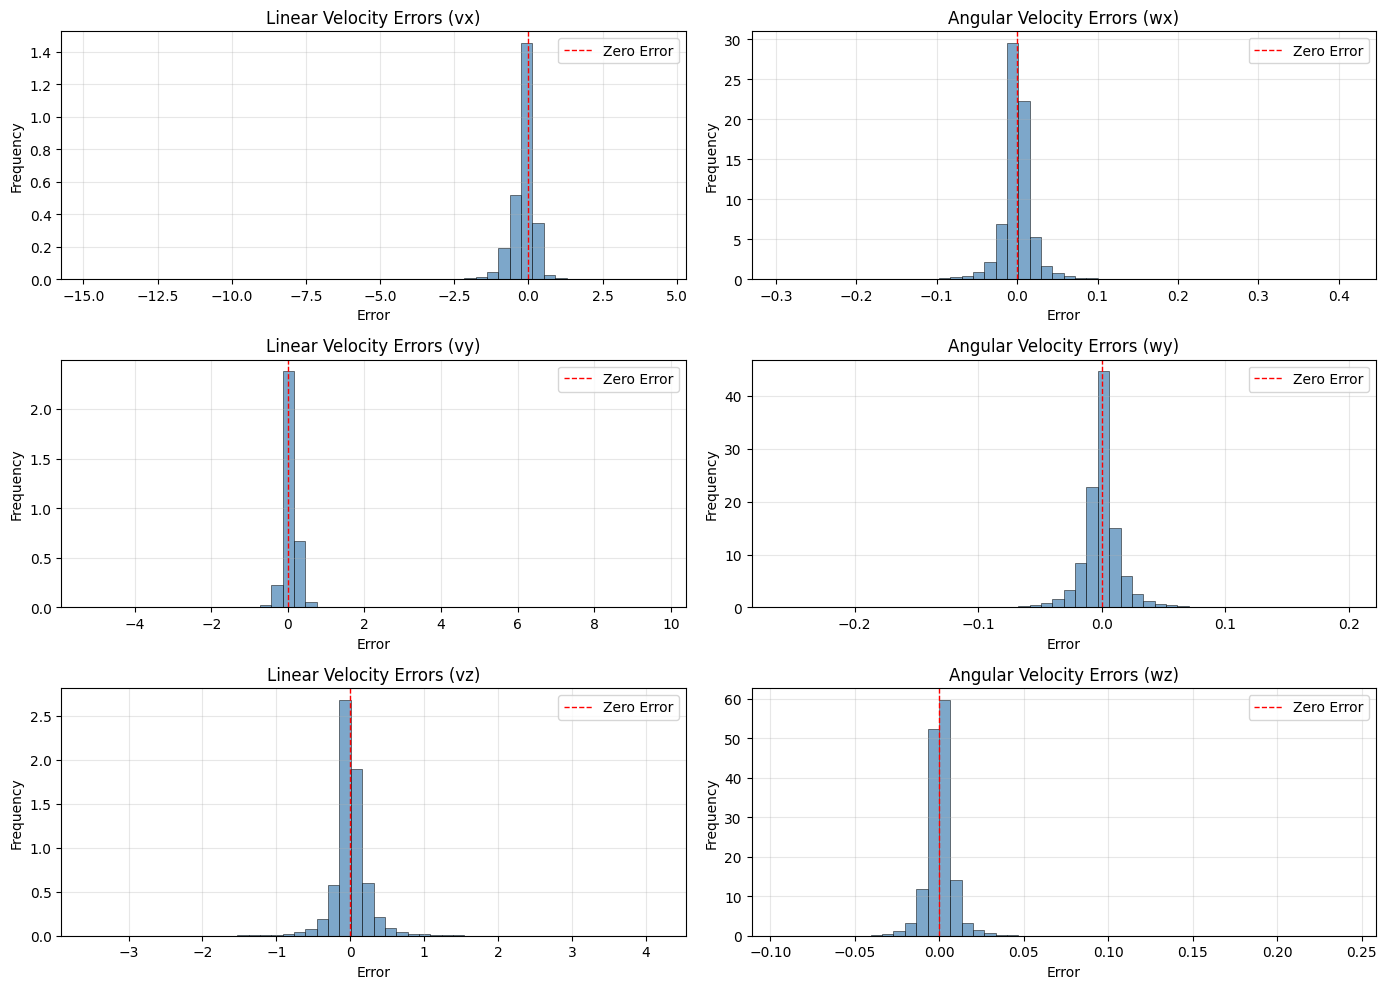

In [10]:
hist = postproc_B.plot_velocity_errors(
    save_path="../pictures/hists/hist_full_kalman.png"
)
plt.show()

Figure saved to ../pictures/hists/hist_full_filtered_kalman.png


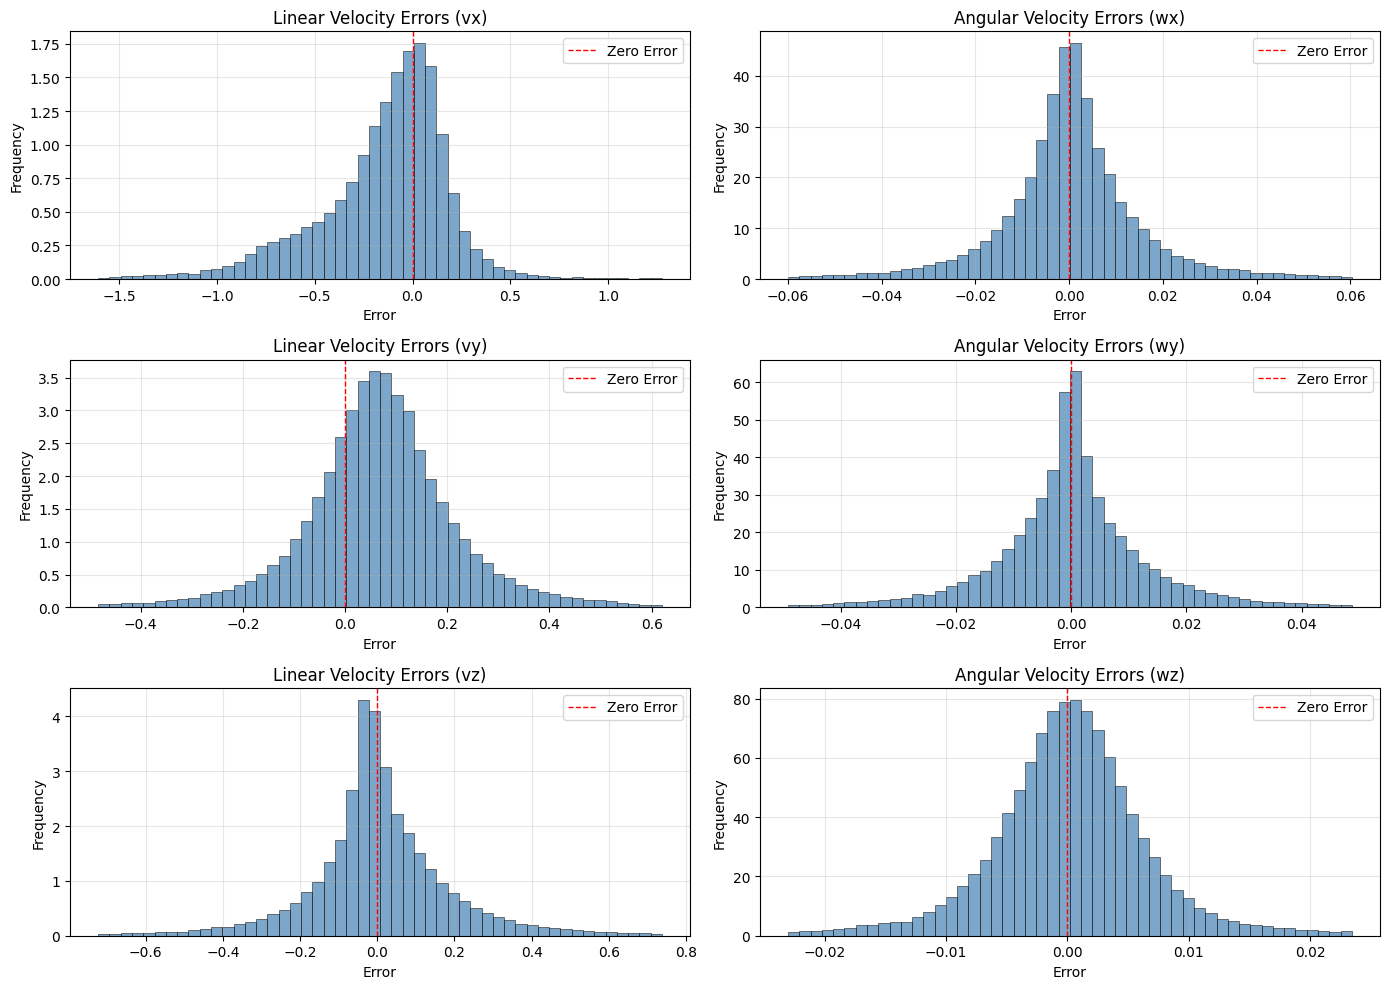

In [11]:
hist = postproc_B.plot_velocity_errors(
    outliers_threshold=3,save_path="../pictures/hists/hist_full_filtered_kalman.png"
)
plt.show()

Figure saved to ../pictures/plots/1_200_500.png
Figure saved to ../pictures/plots/3_200_500.png


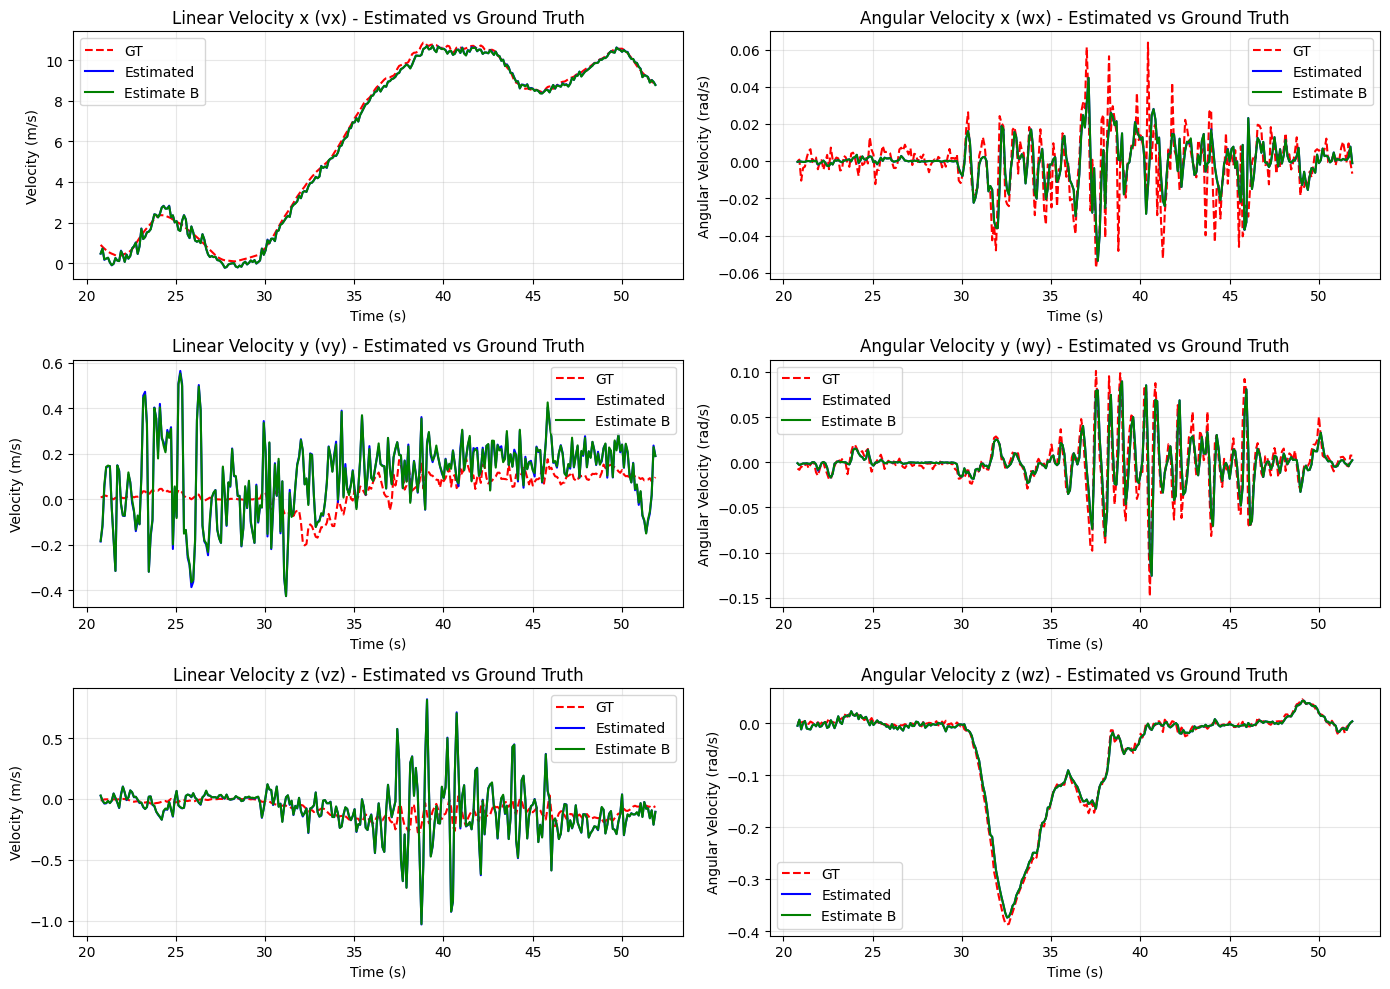

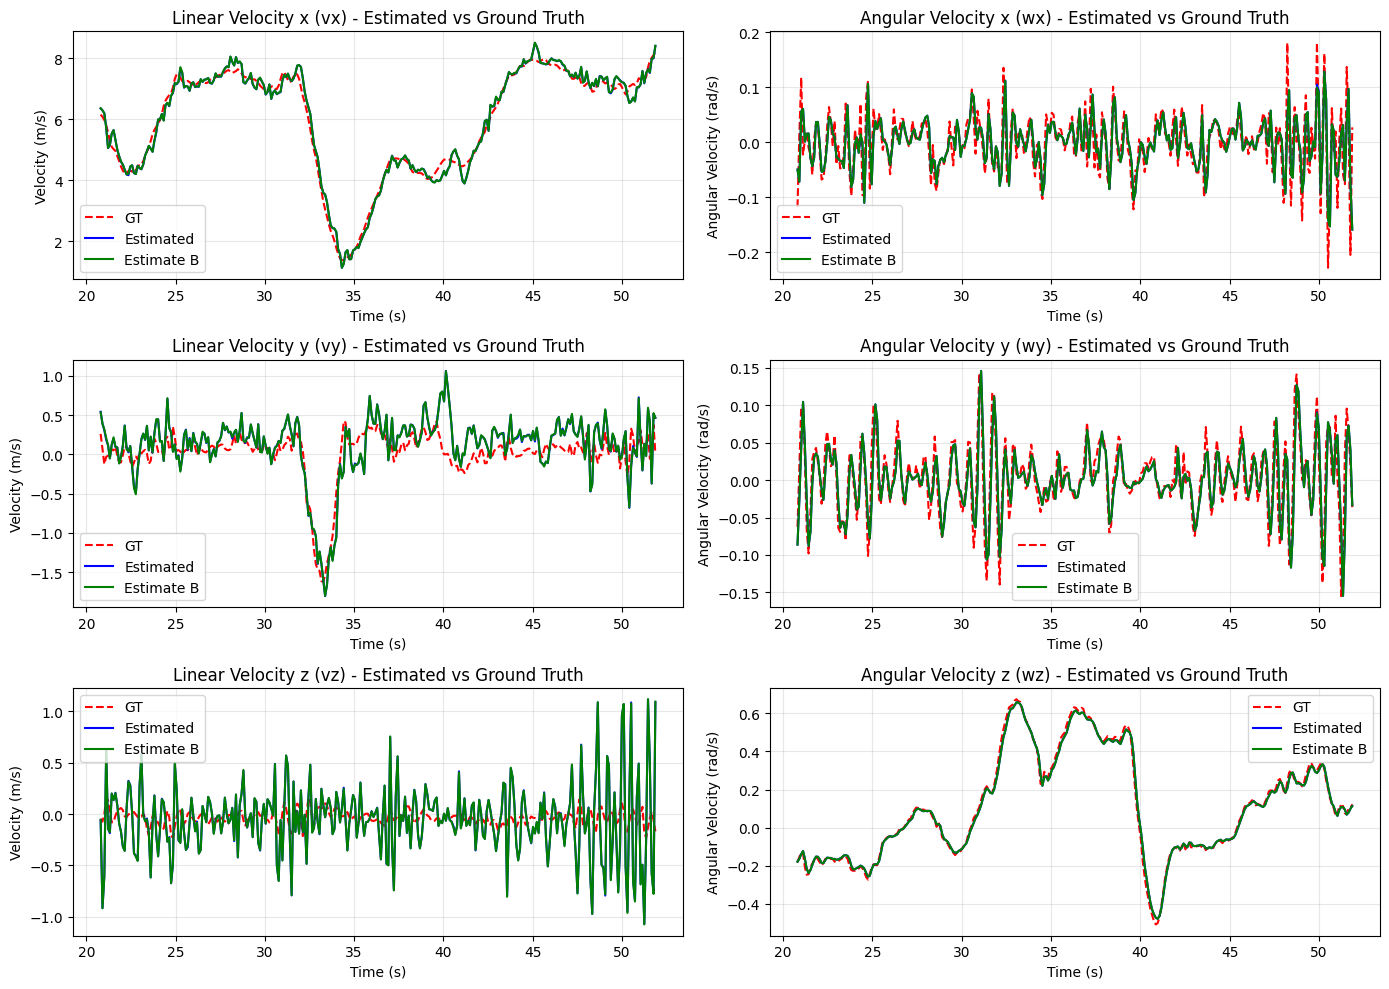

In [12]:
for ride_id, frame_st, frame_en in ride_ids_to_compare:
    fig = postproc_A.plot_velocities(
        ride_segment_id=ride_id,
        frame_st=frame_st,
        frame_en=frame_en,
        compare_against = postproc_B,
        save_path=f"../pictures/plots/{ride_id}_{frame_st}_{frame_en}.png",
    )
plt.show()

### Compare

In [13]:
ttest_related_ride_metrics(
    JSON_A,
    JSON_B,
    alternative="greater",
)

,mean,std,MSE,MAE,q95_abs,RMSE
vx_avg_A,-0.183397,0.434314,0.296939,0.318444,0.891951,0.487595
vx_avg_B,-0.185108,0.425440,0.300305,0.318014,0.865708,0.479560
vx_abs_diff,0.001711,0.008873,-0.003366,0.000429,0.026243,0.008035
vx_rel_diff,-0.933168,2.043039,-1.133434,0.134812,2.942204,1.647956
vx_p_value,0.435358,0.428634,0.518296,0.483501,0.179570,0.436115
vy_avg_A,0.065217,0.158882,0.033649,0.125675,0.343125,0.172876
vy_avg_B,0.064860,0.159559,0.034404,0.124836,0.340951,0.173487
vy_abs_diff,0.000356,-0.000677,-0.000755,0.000839,0.002174,-0.000610
vy_rel_diff,0.546527,-0.426165,-2.242662,0.667612,0.633620,-0.353031
vy_p_value,0.027361,0.642541,0.741306,0.004641,0.029349,0.633444
